# Refactored train/test split pipeline
This notebook orchestrates the original `train_test_split.ipynb` workflow using code extracted into the `src` package.


In [1]:
import os
import sys
import numpy as np

# Allow imports from the project root
sys.path.insert(0, os.path.abspath('..'))

from src.data_prep import prepare_data
from src import regression
from src.pipeline import FEATURE_SETS, plot_feature_histograms, reset_output_dir, run_baseline_regressions
from src.model_comparison import run_model_comparison
from src.classification import run_classification_analysis

In [2]:
# Configuration flags and parameters
RUN_BASELINE_MODELS = True
BASELINE_PLOTTING = False
RANDOM_STATES = [1, 2, 3, 4, 5, 6, 7, 8, 9, 1000000]

RUN_HISTOGRAMS = True
RUN_CORNER = False
RUN_CORNER_BY_DATASET = False
RUN_RESIDUALS = False
RUN_CLASSIFICATION = True
RUN_MODEL_COMPARISON = True

MODEL_COMPARISON_SEEDS = [42, 123, 456, 789, 1010]
CLASSIFICATION_THRESHOLDS = np.arange(0.25, 0.66, 0.05)
CLASSIFICATION_FEATURES = ['tau', 'lin_age_err', 'met', 'met_err', 'logM', 'rad_kpc']

MIX_DATASETS = True

CORNER_FEATURES = ['met', 'tau', 'met_err', 'lin_age_err', 'logM', 'rad_kpc', 'MgFe', 'vdisp', 'DoR']
CORNER_TARGET_DISPLAY_NAME = r'$\mathrm{DoR}$'

RESIDUAL_FEATURES = ['tau', 'met']
RESIDUAL_MODEL_PARAMS = {
    'max_depth': 8,
    'max_features': 0.8,
    'max_samples': 0.7,
    'min_samples_leaf': 3,
    'min_samples_split': 5,
    'n_estimators': 50,
    'random_state': 42,
}


In [3]:
columns = ['vdisp','tau','MgFe', 'met_err', 'lin_age_err','met','rad_kpc','logM','DoR']
train_df, test_df = prepare_data(columns, restricted=False, pc=False, mix_datasets=MIX_DATASETS)

# Keep references for ensemble plots
regression.train_df = train_df
regression.test_df = test_df


['ID', 'RAJ2000', 'DECJ2000', 'zspec_XSH', 'ageUni_at_z', 'Reff_median_KIDS_arcsec', 'Reff_median_KIDS_kpc', 'logM', 'Mstar(10^11)', 'vdisp', 'err_Vdisp_XSH', 'MgFe', 'err_alphafe', 'age_unr', 'age_rmax', 'lin_age_err', 'metal_unr', 'metal_rmax', 'met_err', 'tuni', 'Mtbb3', 'stdev_Mt3', 't_75', 'stdev_t75', 't_final', 'stdev_tifn', 'err_tfin', 'DoR', 'lin_age', 'met', 'SNR', 'rad_kpc', 'tau']
['ID', 'age_noboot', 'metals_noboot', 'age_boot', 'metals_boot', 'age_minus', 'metals_minus', 'ages_plus', 'metal_plus', 'GALAXY ID', 'univ_age', 'MgFe', 'vdisp', 'dor_26', 'logM', 'rad_kpc', 'age_err_mass', 'SNR', '[M/H]_mean_mass', '[M/H]_mean_1', 'DoR', '[M/H]', 'logAge_err', 'logAge', 'lin_age', 'lin_age_err', 'met_err', 'met', 'tau']
        vdisp       tau  MgFe   met_err  lin_age_err       met   rad_kpc  \
0  235.738250  0.080965   0.3  0.017160     0.190062  0.287000  0.502996   
1  211.042349  0.162209   0.2  0.021531     0.448946  0.242117  0.446138   
2  280.829136  0.082736   0.3  0.01

In [4]:
columns = ['vdisp','tau','MgFe', 'met_err', 'lin_age_err','met','rad_kpc','logM','DoR']
train_df, test_df = prepare_data(columns, restricted=False, pc=False, mix_datasets=MIX_DATASETS)

# Keep references for ensemble plots
regression.train_df = train_df
regression.test_df = test_df


['ID', 'RAJ2000', 'DECJ2000', 'zspec_XSH', 'ageUni_at_z', 'Reff_median_KIDS_arcsec', 'Reff_median_KIDS_kpc', 'logM', 'Mstar(10^11)', 'vdisp', 'err_Vdisp_XSH', 'MgFe', 'err_alphafe', 'age_unr', 'age_rmax', 'lin_age_err', 'metal_unr', 'metal_rmax', 'met_err', 'tuni', 'Mtbb3', 'stdev_Mt3', 't_75', 'stdev_t75', 't_final', 'stdev_tifn', 'err_tfin', 'DoR', 'lin_age', 'met', 'SNR', 'rad_kpc', 'tau']
['ID', 'age_noboot', 'metals_noboot', 'age_boot', 'metals_boot', 'age_minus', 'metals_minus', 'ages_plus', 'metal_plus', 'GALAXY ID', 'univ_age', 'MgFe', 'vdisp', 'dor_26', 'logM', 'rad_kpc', 'age_err_mass', 'SNR', '[M/H]_mean_mass', '[M/H]_mean_1', 'DoR', '[M/H]', 'logAge_err', 'logAge', 'lin_age', 'lin_age_err', 'met_err', 'met', 'tau']
        vdisp       tau  MgFe   met_err  lin_age_err       met   rad_kpc  \
0  235.738250  0.080965   0.3  0.017160     0.190062  0.287000  0.502996   
1  211.042349  0.162209   0.2  0.021531     0.448946  0.242117  0.446138   
2  280.829136  0.082736   0.3  0.01

In [5]:
columns = ['vdisp','tau','MgFe', 'met_err', 'lin_age_err','met','rad_kpc','logM','DoR']
train_df, test_df = prepare_data(columns, restricted=False, pc=False, mix_datasets=MIX_DATASETS)

# Keep references for ensemble plots
regression.train_df = train_df
regression.test_df = test_df


['ID', 'RAJ2000', 'DECJ2000', 'zspec_XSH', 'ageUni_at_z', 'Reff_median_KIDS_arcsec', 'Reff_median_KIDS_kpc', 'logM', 'Mstar(10^11)', 'vdisp', 'err_Vdisp_XSH', 'MgFe', 'err_alphafe', 'age_unr', 'age_rmax', 'lin_age_err', 'metal_unr', 'metal_rmax', 'met_err', 'tuni', 'Mtbb3', 'stdev_Mt3', 't_75', 'stdev_t75', 't_final', 'stdev_tifn', 'err_tfin', 'DoR', 'lin_age', 'met', 'SNR', 'rad_kpc', 'tau']
['ID', 'age_noboot', 'metals_noboot', 'age_boot', 'metals_boot', 'age_minus', 'metals_minus', 'ages_plus', 'metal_plus', 'GALAXY ID', 'univ_age', 'MgFe', 'vdisp', 'dor_26', 'logM', 'rad_kpc', 'age_err_mass', 'SNR', '[M/H]_mean_mass', '[M/H]_mean_1', 'DoR', '[M/H]', 'logAge_err', 'logAge', 'lin_age', 'lin_age_err', 'met_err', 'met', 'tau']
        vdisp       tau  MgFe   met_err  lin_age_err       met   rad_kpc  \
0  235.738250  0.080965   0.3  0.017160     0.190062  0.287000  0.502996   
1  211.042349  0.162209   0.2  0.021531     0.448946  0.242117  0.446138   
2  280.829136  0.082736   0.3  0.01

In [6]:
columns = ['vdisp','tau','MgFe', 'met_err', 'lin_age_err','met','rad_kpc','logM','DoR']
train_df, test_df = prepare_data(columns, restricted=False, pc=False, mix_datasets=MIX_DATASETS)

# Keep references for ensemble plots
regression.train_df = train_df
regression.test_df = test_df


['ID', 'RAJ2000', 'DECJ2000', 'zspec_XSH', 'ageUni_at_z', 'Reff_median_KIDS_arcsec', 'Reff_median_KIDS_kpc', 'logM', 'Mstar(10^11)', 'vdisp', 'err_Vdisp_XSH', 'MgFe', 'err_alphafe', 'age_unr', 'age_rmax', 'lin_age_err', 'metal_unr', 'metal_rmax', 'met_err', 'tuni', 'Mtbb3', 'stdev_Mt3', 't_75', 'stdev_t75', 't_final', 'stdev_tifn', 'err_tfin', 'DoR', 'lin_age', 'met', 'SNR', 'rad_kpc', 'tau']
['ID', 'age_noboot', 'metals_noboot', 'age_boot', 'metals_boot', 'age_minus', 'metals_minus', 'ages_plus', 'metal_plus', 'GALAXY ID', 'univ_age', 'MgFe', 'vdisp', 'dor_26', 'logM', 'rad_kpc', 'age_err_mass', 'SNR', '[M/H]_mean_mass', '[M/H]_mean_1', 'DoR', '[M/H]', 'logAge_err', 'logAge', 'lin_age', 'lin_age_err', 'met_err', 'met', 'tau']
        vdisp       tau  MgFe   met_err  lin_age_err       met   rad_kpc  \
0  235.738250  0.080965   0.3  0.017160     0.190062  0.287000  0.502996   
1  211.042349  0.162209   0.2  0.021531     0.448946  0.242117  0.446138   
2  280.829136  0.082736   0.3  0.01

In [7]:
columns = ['vdisp','tau','MgFe', 'met_err', 'lin_age_err','met','rad_kpc','logM','DoR']
train_df, test_df = prepare_data(columns, restricted=False, pc=False, mix_datasets=MIX_DATASETS)

# Keep references for ensemble plots
regression.train_df = train_df
regression.test_df = test_df


['ID', 'RAJ2000', 'DECJ2000', 'zspec_XSH', 'ageUni_at_z', 'Reff_median_KIDS_arcsec', 'Reff_median_KIDS_kpc', 'logM', 'Mstar(10^11)', 'vdisp', 'err_Vdisp_XSH', 'MgFe', 'err_alphafe', 'age_unr', 'age_rmax', 'lin_age_err', 'metal_unr', 'metal_rmax', 'met_err', 'tuni', 'Mtbb3', 'stdev_Mt3', 't_75', 'stdev_t75', 't_final', 'stdev_tifn', 'err_tfin', 'DoR', 'lin_age', 'met', 'SNR', 'rad_kpc', 'tau']
['ID', 'age_noboot', 'metals_noboot', 'age_boot', 'metals_boot', 'age_minus', 'metals_minus', 'ages_plus', 'metal_plus', 'GALAXY ID', 'univ_age', 'MgFe', 'vdisp', 'dor_26', 'logM', 'rad_kpc', 'age_err_mass', 'SNR', '[M/H]_mean_mass', '[M/H]_mean_1', 'DoR', '[M/H]', 'logAge_err', 'logAge', 'lin_age', 'lin_age_err', 'met_err', 'met', 'tau']
        vdisp       tau  MgFe   met_err  lin_age_err       met   rad_kpc  \
0  235.738250  0.080965   0.3  0.017160     0.190062  0.287000  0.502996   
1  211.042349  0.162209   0.2  0.021531     0.448946  0.242117  0.446138   
2  280.829136  0.082736   0.3  0.01

In [8]:
columns = ['vdisp','tau','MgFe', 'met_err', 'lin_age_err','met','rad_kpc','logM','DoR']
train_df, test_df = prepare_data(columns, restricted=False, pc=False, mix_datasets=MIX_DATASETS)

# Keep references for ensemble plots
regression.train_df = train_df
regression.test_df = test_df


['ID', 'RAJ2000', 'DECJ2000', 'zspec_XSH', 'ageUni_at_z', 'Reff_median_KIDS_arcsec', 'Reff_median_KIDS_kpc', 'logM', 'Mstar(10^11)', 'vdisp', 'err_Vdisp_XSH', 'MgFe', 'err_alphafe', 'age_unr', 'age_rmax', 'lin_age_err', 'metal_unr', 'metal_rmax', 'met_err', 'tuni', 'Mtbb3', 'stdev_Mt3', 't_75', 'stdev_t75', 't_final', 'stdev_tifn', 'err_tfin', 'DoR', 'lin_age', 'met', 'SNR', 'rad_kpc', 'tau']
['ID', 'age_noboot', 'metals_noboot', 'age_boot', 'metals_boot', 'age_minus', 'metals_minus', 'ages_plus', 'metal_plus', 'GALAXY ID', 'univ_age', 'MgFe', 'vdisp', 'dor_26', 'logM', 'rad_kpc', 'age_err_mass', 'SNR', '[M/H]_mean_mass', '[M/H]_mean_1', 'DoR', '[M/H]', 'logAge_err', 'logAge', 'lin_age', 'lin_age_err', 'met_err', 'met', 'tau']
        vdisp       tau  MgFe   met_err  lin_age_err       met   rad_kpc  \
0  235.738250  0.080965   0.3  0.017160     0.190062  0.287000  0.502996   
1  211.042349  0.162209   0.2  0.021531     0.448946  0.242117  0.446138   
2  280.829136  0.082736   0.3  0.01

In [9]:
# Prepare output directory used throughout the pipeline
reset_output_dir('outputs/tests')


In [ ]:
if RUN_BASELINE_MODELS:
    run_baseline_regressions(train_df, test_df, RANDOM_STATES, plotting=BASELINE_PLOTTING)
    regression.print_results_summary()
    ensemble_results = regression.calculate_ensemble_metrics()


/Users/charl/Programming/AS01_E_INSPIRE/src/regression.py:185: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_summary = pd.concat([results_summary, pd.DataFrame({


In [ ]:
if RUN_HISTOGRAMS:
    plot_feature_histograms(train_df, test_df)


In [ ]:
if RUN_CORNER:
    regression.create_corner_plots(
        test_df,
        CORNER_FEATURES,
        target='DoR',
        target_display_name=CORNER_TARGET_DISPLAY_NAME,
    )
    regression.create_corner_plots(
        train_df,
        CORNER_FEATURES,
        target='DoR',
        target_display_name=CORNER_TARGET_DISPLAY_NAME,
    )


In [ ]:
if RUN_CORNER_BY_DATASET:
    feature_display_names = {
        'met': r'$\mathrm{[M/H]}$',
        'tau': r'$\mathrm{\tau_{\rm rel}}$',
        'met_err': r'$\Delta{\mathrm{[M/H]}}$',
        'lin_age_err': r'$\Delta{\mathrm{Age}}$',
        'logM': r'$\log(M/M_{\odot})$',
        'rad_kpc': r'$R \, \mathrm{(kpc)}$',
        'MgFe': r'$\mathrm{[Mg/Fe]}$',
        'vdisp': r'$\sigma \star \mathrm{(km/s)}$',
        'DoR': r'$\mathrm{DoR}$',
    }
    regression.plot_features_by_dataset(
        train_df,
        test_df,
        CORNER_FEATURES,
        feature_display_names=feature_display_names,
    )


In [ ]:
if RUN_RESIDUALS:
    regression.create_residual_analysis_report(
        train_df,
        test_df,
        RESIDUAL_FEATURES,
        'DoR',
        RESIDUAL_MODEL_PARAMS,
    )


In [ ]:
if RUN_CLASSIFICATION:
    cv_results = run_classification_analysis(CLASSIFICATION_THRESHOLDS, CLASSIFICATION_FEATURES)


['ID', 'RAJ2000', 'DECJ2000', 'zspec_XSH', 'ageUni_at_z', 'Reff_median_KIDS_arcsec', 'Reff_median_KIDS_kpc', 'logM', 'Mstar(10^11)', 'vdisp', 'err_Vdisp_XSH', 'MgFe', 'err_alphafe', 'age_unr', 'age_rmax', 'lin_age_err', 'metal_unr', 'metal_rmax', 'met_err', 'tuni', 'Mtbb3', 'stdev_Mt3', 't_75', 'stdev_t75', 't_final', 'stdev_tifn', 'err_tfin', 'DoR', 'lin_age', 'met', 'SNR', 'rad_kpc', 'tau']
['ID', 'age_noboot', 'metals_noboot', 'age_boot', 'metals_boot', 'age_minus', 'metals_minus', 'ages_plus', 'metal_plus', 'GALAXY ID', 'univ_age', 'MgFe', 'vdisp', 'dor_26', 'logM', 'rad_kpc', 'age_err_mass', 'SNR', '[M/H]_mean_mass', '[M/H]_mean_1', 'DoR', '[M/H]', 'logAge_err', 'logAge', 'lin_age', 'lin_age_err', 'met_err', 'met', 'tau']
        vdisp       tau  MgFe   met_err  lin_age_err       met   rad_kpc  \
0  235.738250  0.080965   0.3  0.017160     0.190062  0.287000  0.502996   
1  211.042349  0.162209   0.2  0.021531     0.448946  0.242117  0.446138   
2  280.829136  0.082736   0.3  0.01


Running model comparison with 5 random seeds: [42, 123, 456, 789, 1010]...
['ID', 'RAJ2000', 'DECJ2000', 'zspec_XSH', 'ageUni_at_z', 'Reff_median_KIDS_arcsec', 'Reff_median_KIDS_kpc', 'logM', 'Mstar(10^11)', 'vdisp', 'err_Vdisp_XSH', 'MgFe', 'err_alphafe', 'age_unr', 'age_rmax', 'lin_age_err', 'metal_unr', 'metal_rmax', 'met_err', 'tuni', 'Mtbb3', 'stdev_Mt3', 't_75', 'stdev_t75', 't_final', 'stdev_tifn', 'err_tfin', 'DoR', 'lin_age', 'met', 'SNR', 'rad_kpc', 'tau']
['ID', 'age_noboot', 'metals_noboot', 'age_boot', 'metals_boot', 'age_minus', 'metals_minus', 'ages_plus', 'metal_plus', 'GALAXY ID', 'univ_age', 'MgFe', 'vdisp', 'dor_26', 'logM', 'rad_kpc', 'age_err_mass', 'SNR', '[M/H]_mean_mass', '[M/H]_mean_1', 'DoR', '[M/H]', 'logAge_err', 'logAge', 'lin_age', 'lin_age_err', 'met_err', 'met', 'tau']
        vdisp       tau  MgFe   met_err  lin_age_err       met   rad_kpc  \
0  235.738250  0.080965   0.3  0.017160     0.190062  0.287000  0.502996   
1  211.042349  0.162209   0.2  0.02

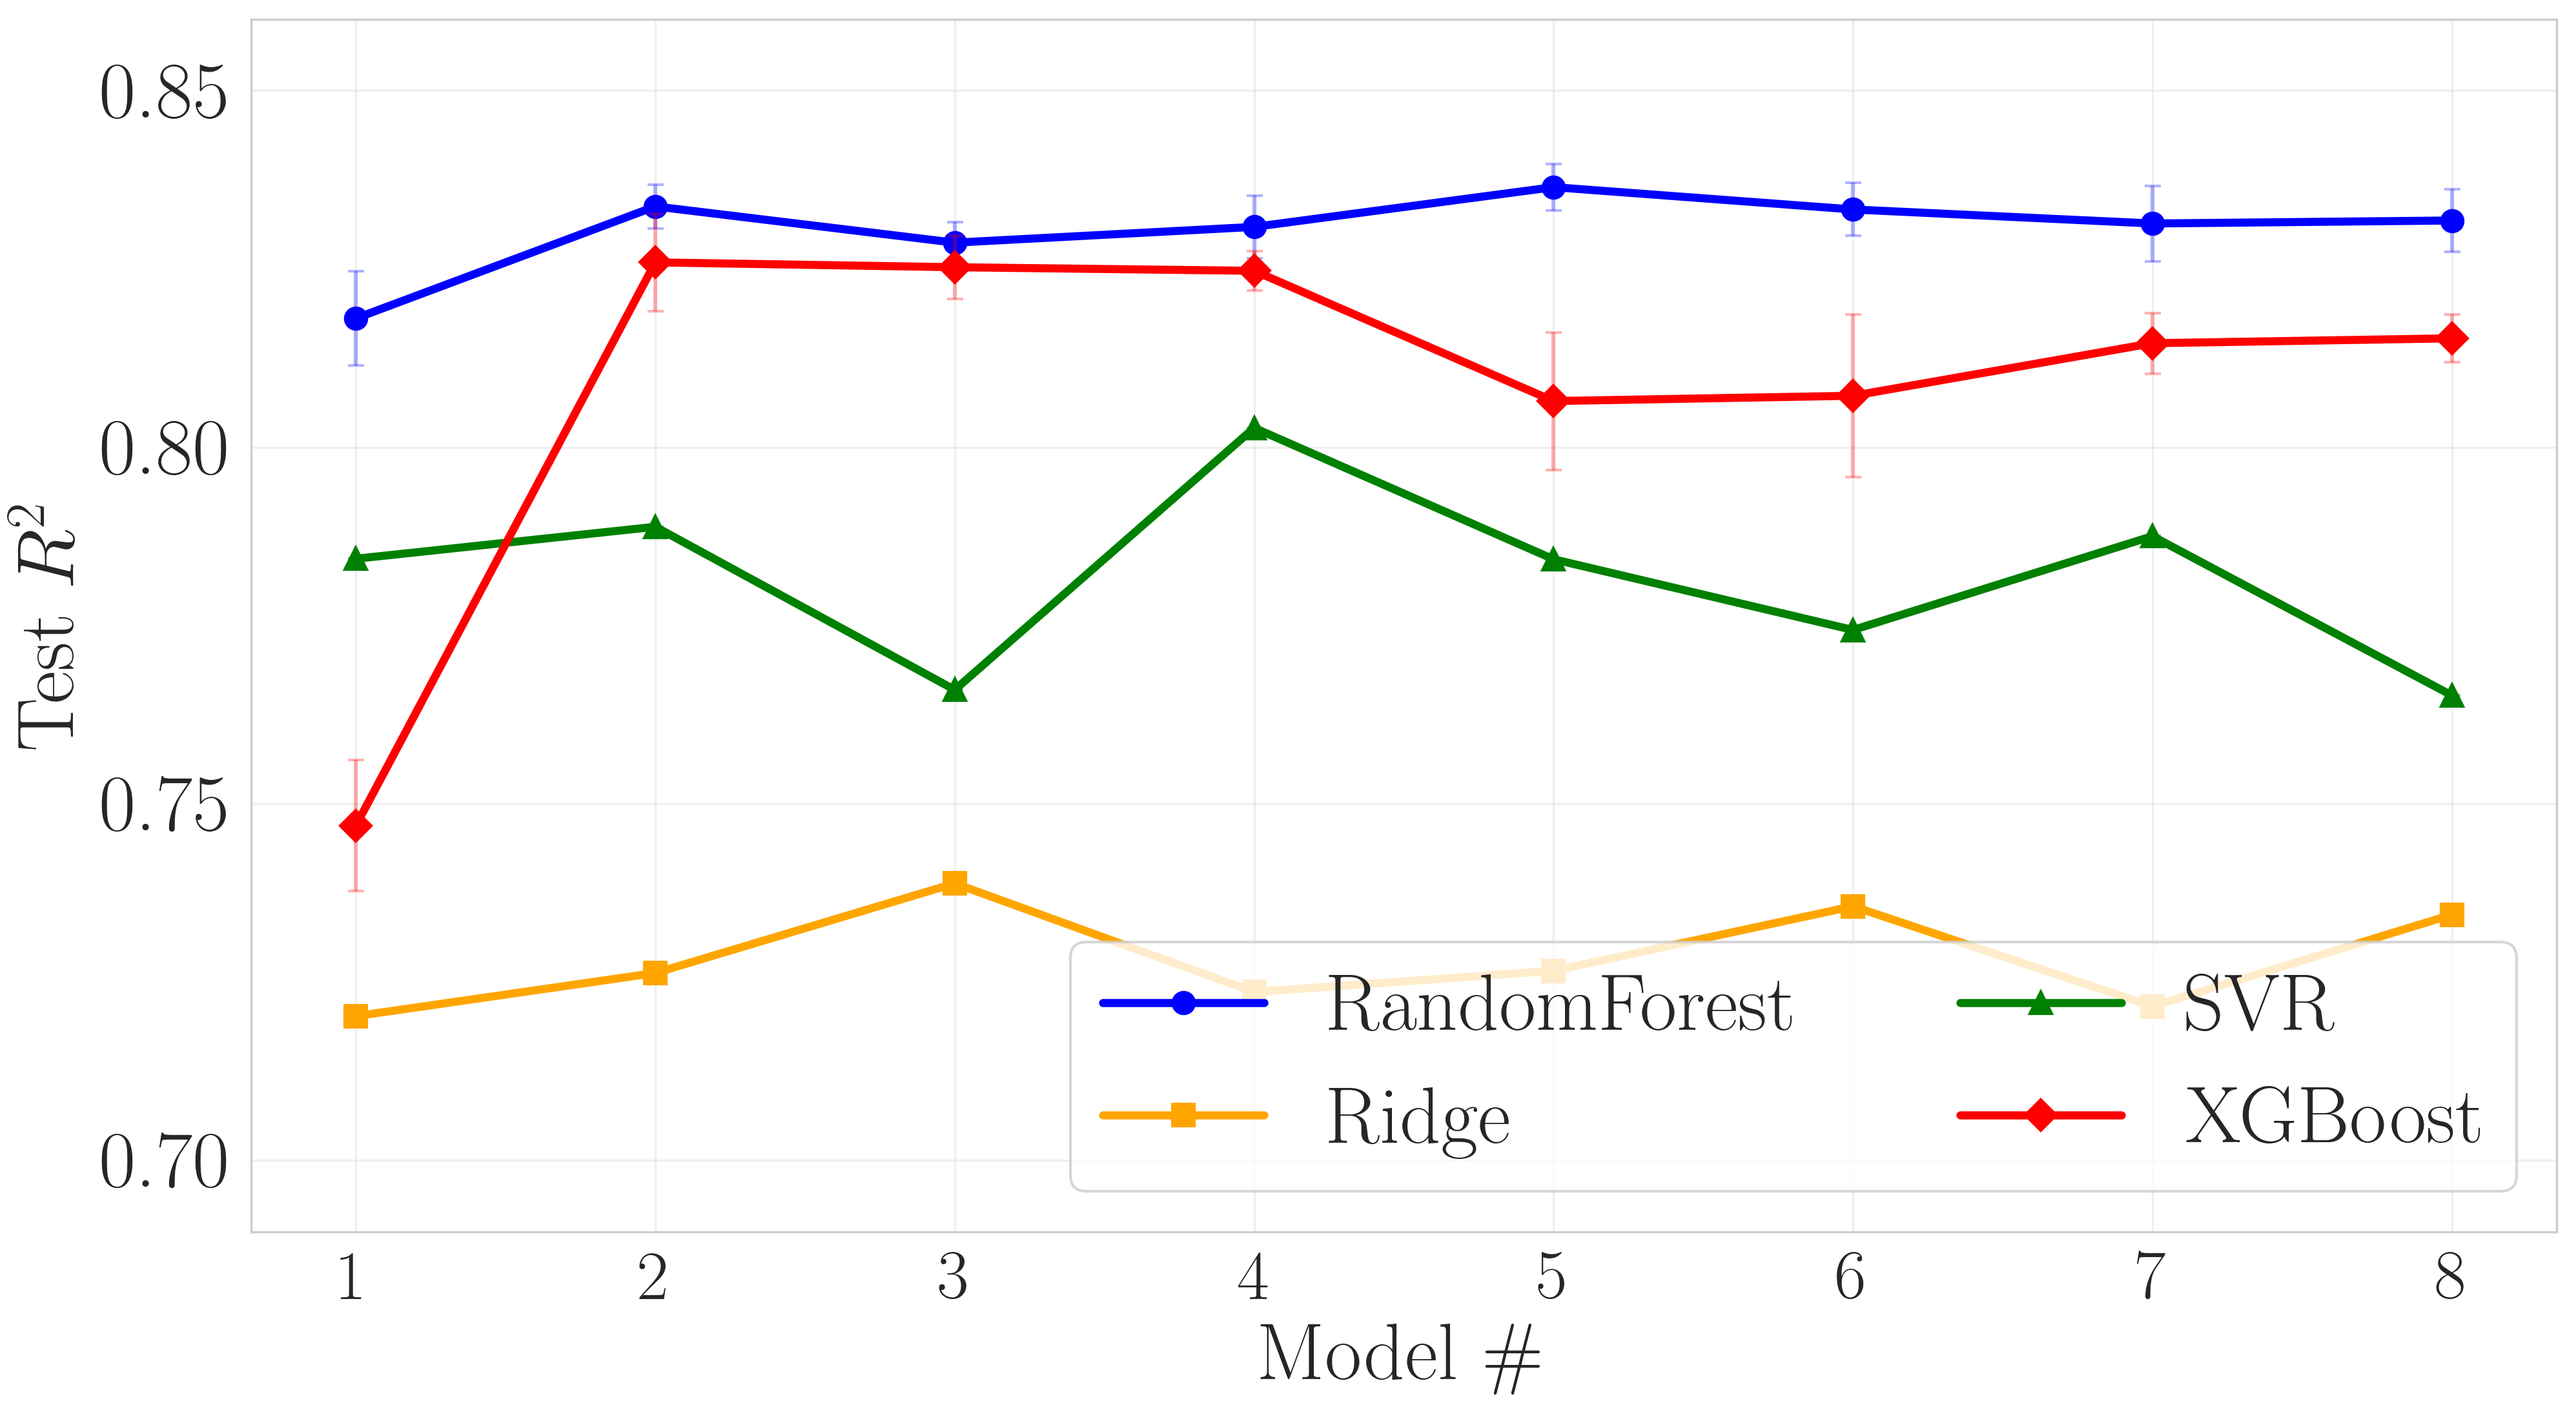

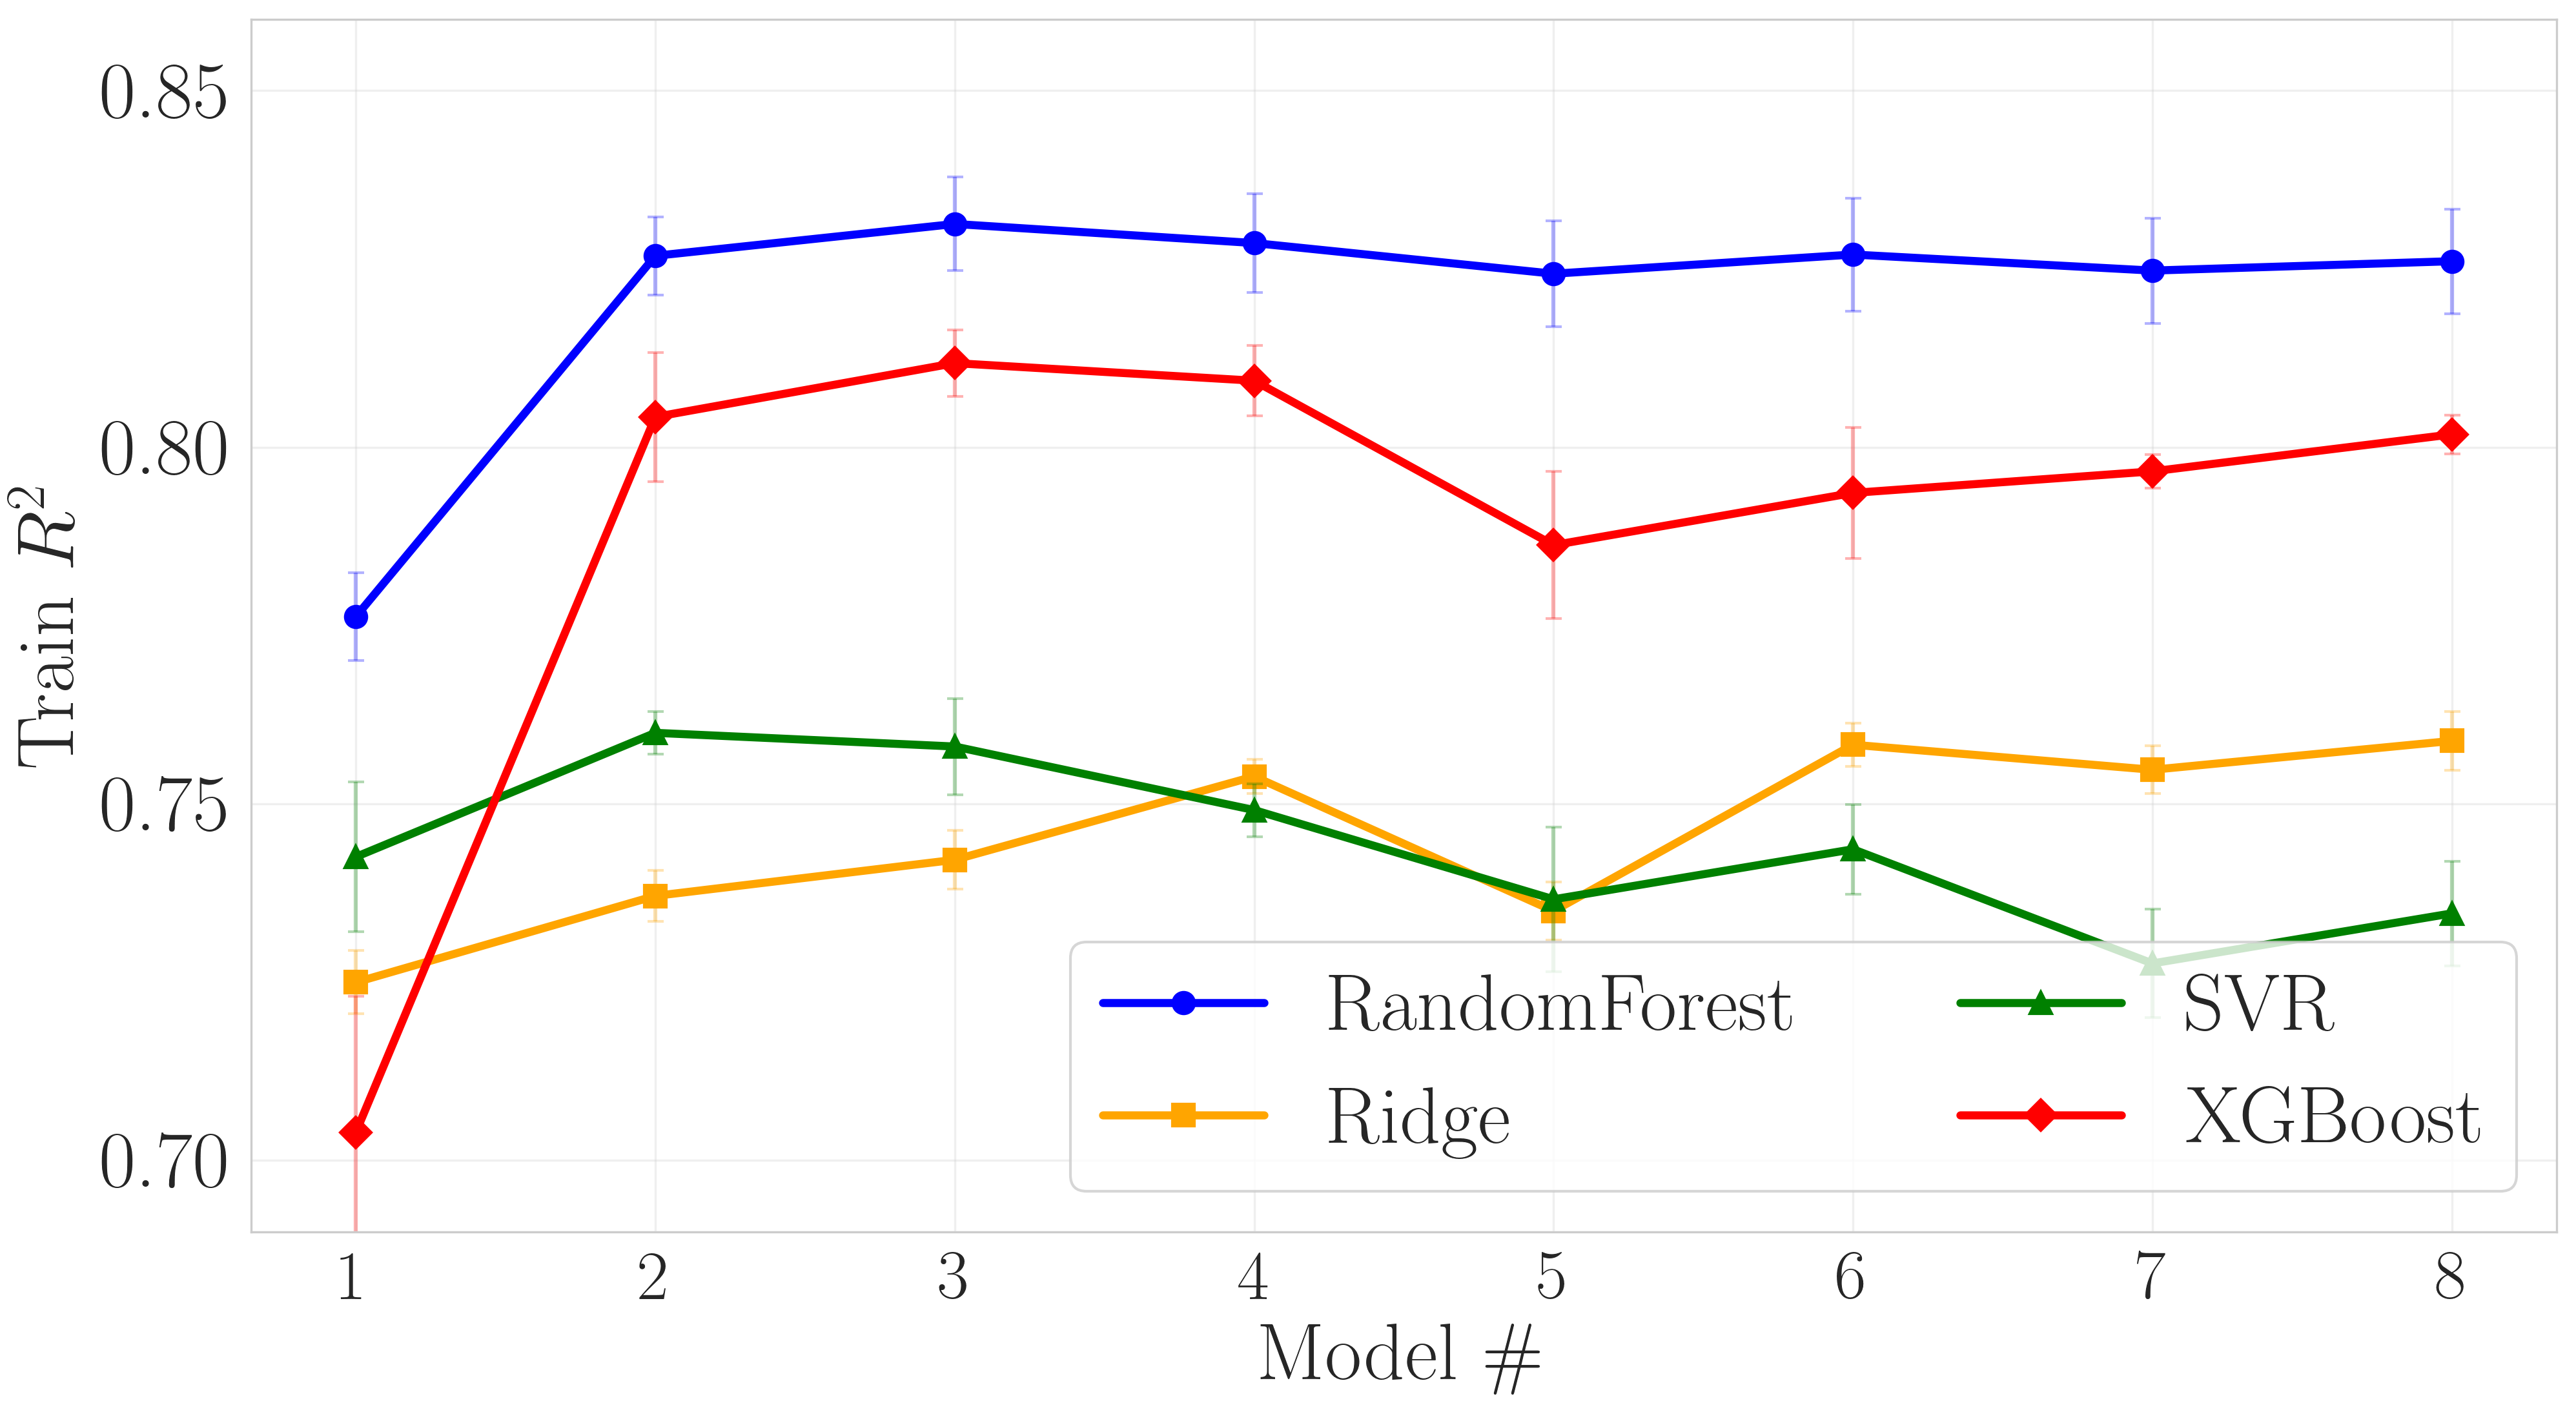

Created separate test and training performance plots
Model comparison completed and results saved to ../outputs/tests/


In [ ]:
if RUN_MODEL_COMPARISON:
    results_df, agg_results = run_model_comparison(MODEL_COMPARISON_SEEDS, True)
    print('Model comparison completed and results saved to outputs/tests/')